## Simple Linear Regression

In [1]:
!pip install matplotlib
!pip install numpy


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
x1 = [
    0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 
    5.5, 6.0, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0, 9.5, 10.0,
    11.0, 12.0, 13.0, 14.0, 15.0
]
y = [
    41, 44, 42, 51, 48, 55, 60, 58, 64, 69, 
    71, 70, 78, 81, 84, 80, 88, 92, 90, 95,
    96, 98, 99, 97, 100
]

In [3]:
totallen = len(x1)
trainlen = (totallen/10)*8
print(totallen,trainlen)

25 20.0


In [4]:
import random

indices = list(range(len(x1)))
random.shuffle(indices)

train_x = []
train_y = []
test_x = []
test_y = []

for i in range(0, int(trainlen)):
    idx = indices[i]
    train_x.append(x1[idx])
    train_y.append(y[idx])

for i in range(int(trainlen), len(x1)):
    idx = indices[i]
    test_x.append(x1[idx])
    test_y.append(y[idx])

print(train_x)
print(train_y)
print(test_x)
print(test_y)

[9.5, 9.0, 6.5, 7.5, 3.5, 2.0, 13.0, 3.0, 10.0, 1.0, 1.5, 4.0, 0.5, 8.5, 7.0, 5.5, 4.5, 11.0, 2.5, 5.0]
[90, 92, 78, 84, 60, 51, 99, 55, 95, 44, 42, 58, 41, 88, 81, 71, 64, 96, 48, 69]
[6.0, 14.0, 15.0, 8.0, 12.0]
[70, 97, 100, 80, 98]


In [5]:
def findslope(x,y):
    xmean = sum(x)/len(x)
    ymean = sum(y)/len(y)
    print(xmean)
    print(ymean)
    num = 0.0
    den = 0.0
    for i in range (0,len(x)):
        num = num + ((x[i]-xmean)*(y[i]-ymean))
        den = den + (x[i]-xmean)**2
    return num/den

m1 = findslope(train_x,train_y)
print(m1)

5.75
70.3
5.3746192893400995


In [6]:
x1mean = sum(train_x)/len(train_x)
ymean = sum(train_y)/len(train_y)

c = ymean - (m1*x1mean)

In [7]:
def func(x):
    y = []
    for i in range (0,len(x)):
        y.append((m1*x[i])+c)
    return y
y_train_pred = func(train_x)
y_test_pred = func(test_x)
print(y_train_pred)
print(y_test_pred)

[90.45482233502537, 87.76751269035532, 74.33096446700507, 79.70558375634516, 58.20710659898477, 50.145177664974625, 109.26598984771573, 55.51979695431473, 93.14213197969542, 44.77055837563452, 47.45786802030457, 60.894416243654824, 42.08324873096448, 85.08020304568527, 77.01827411167511, 68.95634517766497, 63.581725888324875, 98.51675126903552, 52.83248730964468, 66.26903553299492]
[71.64365482233502, 114.6406091370558, 120.01522842639591, 82.39289340101521, 103.89137055837563]


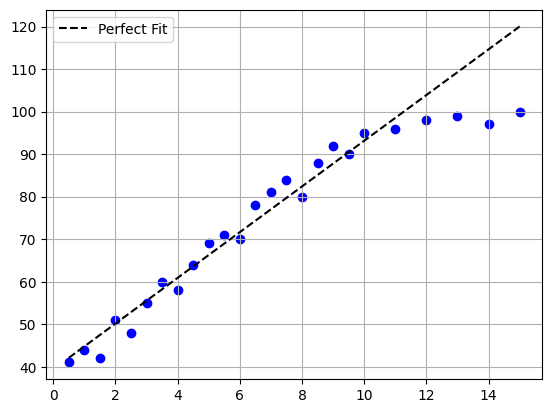

In [8]:
import matplotlib.pyplot as plt
plt.scatter(x1,y,color="blue")
plt.plot(x1,func(x1), color='black', linestyle='--', label='Perfect Fit')
plt.legend()
plt.grid(True)
plt.show()

## Multiple Linear Regression

In [10]:
import numpy as np
x = np.array([[4,1,3],[9,2,1],[8,3,2],[8,1,1],[7,1,4],[5,0,2]])
y = np.array([52,51,50,52,70,60])
z = np.array([1,1,1])
x = np.c_[np.ones((x.shape[0], 1)), x]
print(x)
print(y)

[[1. 4. 1. 3.]
 [1. 9. 2. 1.]
 [1. 8. 3. 2.]
 [1. 8. 1. 1.]
 [1. 7. 1. 4.]
 [1. 5. 0. 2.]]
[52 51 50 52 70 60]


In [11]:
x_ = x.T.dot(x)
x_inv = np.linalg.inv(x_)
beta = x_inv.dot(x.T.dot(y))
print(beta)

[28.70422535  3.12676056 -6.          6.35211268]


In [12]:
test = np.array([1,6,1,1])
pred = test.dot(beta)
print(pred)

47.81690140845075


In [13]:
intercept = beta[0]
coefficients = beta[1:]

print("Intercept:", intercept)
print("Coefficients:", coefficients)

Intercept: 28.704225352112644
Coefficients: [ 3.12676056 -6.          6.35211268]


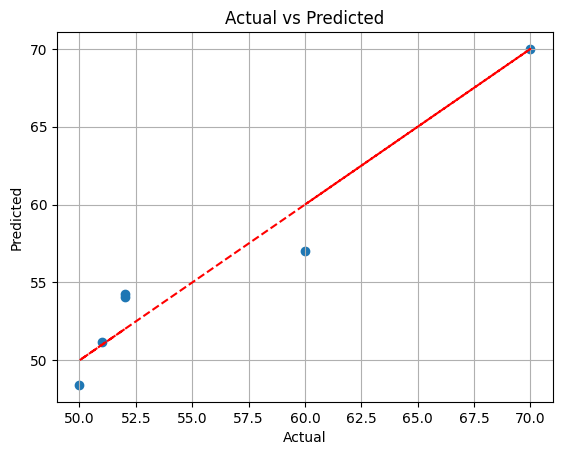

In [16]:
plt.scatter(y, x.dot(beta))

# Add perfect prediction line
plt.plot(y, y, color='red', linestyle='--')

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.grid(True)
plt.show()

In [17]:
y_pred = x.dot(beta)

# mean of y
y_mean = np.mean(y)

# R² calculation
ss_res = np.sum((y - y_pred)**2)   # residual error
ss_tot = np.sum((y - y_mean)**2)   # total variance

r2 = 1 - (ss_res / ss_tot)

print("R² Score:", r2)

R² Score: 0.9320801792713636


In [18]:
mae = np.mean(np.abs(y - y_pred))
print("MAE:", mae)

MAE: 1.5117370892019153


In [19]:
mse = np.mean((y - y_pred)**2)
print("MSE:", mse)

MSE: 3.4507042253521125


In [20]:
rmse = np.sqrt(mse)
print("RMSE:", rmse)

RMSE: 1.8576071235199634
